In [1]:
!pip install -q bitsandbytes accelerate
!pip install -q git+https://github.com/huggingface/transformers.git@main
!pip install -q git+https://github.com/huggingface/peft.git@main

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 17.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml)

In [2]:
import pandas as pd
from google.colab import files
import os
filename = "Q2_20230202_majority 1.csv"

if not os.path.exists(filename):
  print(f"'{filename}' not found. Please upload the file.")
  uploaded = files.upload()
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("Q2_20230202_majority 1.csv")
df.sample(5)

'Q2_20230202_majority 1.csv' not found. Please upload the file.


Saving Q2_20230202_majority 1.csv to Q2_20230202_majority 1.csv


,tweet_id,created_at,tweet,label_majority,month
19,1.421777e+18,2021-08-01 10:17:48+00:00,"""people keep asking for magic dust. it doesn't exist”, says @drmikeryan..“only magic dust we do have is vaccination. problem is, we're not sprinkling that evenly around the world, and we're working against ourselves.""",in-favor,21-Aug
824,1.437560e+18,2021-09-13 23:34:56+00:00,"just a reminder that people are losing their jobs for not taking the vaccine, but it’s optional for biden’s staff members as well as congress!",against,21-Sep
4070,1.376639e+18,2021-03-29 20:56:09+00:00,"before the vaccine, democrats didn’t wear masks at five star restaurants and salons. ..now after the vaccine, they still make you wear a mask.",against,21-Mar
2544,1.417107e+18,2021-07-19 13:01:33+00:00,"here's the update 🥁💥..happy to announce that, first time our telugu cdp going to release this year...!!.designed by 🔥..release date and time 🕺: july 26th 2021, @ 6pm !..stay home, stay safe, get vaccinated ❤️.#dhanushtelugucdpon26th #karnan",in-favor,21-Jul
4068,1.376570e+18,2021-03-29 16:20:24+00:00,"gee, wonder why people hesitate to get vacc’d?.",neutral-or-unclear,21-Mar


In [3]:
def format_prompt(tweet):
    return (
        f'What is the stance of the **author** of the  following tweet toward COVID-19 vaccines?\n'
        f'Tweet: "{tweet}"\n'
        f'Respond with one of the following: "in-favor", "against", "neutral-or-unclear".'
    )


df['prompt'] = df['tweet'].apply(format_prompt)
df['target'] = df['label_majority'].str.strip()
print("prompt loaded")

prompt loaded


In [4]:
# Count how many examples you'd like total
TOTAL = 5000  # example value
p_in_favor = 0.505
p_against = 0.314
p_neutral = 0.181

n_in_favor = int(TOTAL * p_in_favor)
n_against = int(TOTAL * p_against)
n_neutral = TOTAL - n_in_favor - n_against  # remaining

# Subsample with proportional distribution
df_in_favor = df[df['target'] == 'in-favor'].sample(n=n_in_favor, random_state=42)
df_against  = df[df['target'] == 'against'].sample(n=n_against, random_state=42)
df_neutral  = df[df['target'] == 'neutral-or-unclear'].sample(n=n_neutral, random_state=42)

df_balanced = pd.concat([df_in_favor, df_against, df_neutral]).sample(frac=1, random_state=42)  # shuffle

print("Balanced dataset loaded")

Balanced dataset loaded


In [5]:
from datasets import Dataset
from transformers import AutoTokenizer

# Convert to Dataset
dataset = Dataset.from_pandas(df_balanced[['prompt','target']])
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")

# Tokenize
def tokenize(example):
    inputs = tokenizer(example['prompt'], max_length=256, truncation=True, padding="max_length")
    labels = tokenizer(example['target'], max_length=8, truncation=True, padding="max_length")
    inputs['labels'] = labels.input_ids
    return inputs

tokenized = dataset.map(tokenize, batched=True)
train_test = tokenized.train_test_split(test_size=0.2)
train_dataset = train_test['train']
eval_dataset  = train_test['test']

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [6]:
import peft
print("PEFT version:", peft.__version__)
print("PEFT path:", peft.__file__)

PEFT version: 0.16.1.dev0
PEFT path: /usr/local/lib/python3.11/dist-packages/peft/__init__.py


In [7]:
from transformers import AutoModelForSeq2SeqLM
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large", load_in_8bit=True)
model = prepare_model_for_kbit_training(model)  # cast some parts to fp32, enable grad ckpt etc.

# Configure LoRA: tune down 'r' or 'lora_alpha' if still OOM.
lora_config = LoraConfig(
    task_type="SEQ_2_SEQ_LM",
    r=8,                # LoRA rank; try r=4 or 8
    lora_alpha=16,      # LoRA scaling; often between 16-32
    lora_dropout=0.1,
    target_modules=["q", "v"]  # T5 uses q, v projection layers for LoRA
)
model = get_peft_model(model, lora_config)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [8]:
model.print_trainable_parameters()

trainable params: 2,359,296 || all params: 785,509,376 || trainable%: 0.3004


In [10]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq, EarlyStoppingCallback

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    learning_rate=5e-5,
    per_device_train_batch_size=4,   # 2->8
    per_device_eval_batch_size=4,    #
    gradient_accumulation_steps=2,   # 4->1
    num_train_epochs=5,
    logging_steps=1,                 #50
    eval_steps=250,
    save_steps=250,
    eval_strategy="steps",
    save_strategy="steps",
    logging_dir='./logs',
    fp16=False,                      # 8-bit already reduces precision
    max_steps=-1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",

)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)

/tmp/ipython-input-10-796523754.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [11]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("Training Started")
trainer.train()
print("Training Completed")

Training Started


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss


Step,Training Loss,Validation Loss
250,1.722400,2.069362
500,0.846900,0.187212
750,0.356800,0.118009
1000,0.165200,0.117313
1250,0.187000,0.111844
1500,0.247900,0.110200
1750,0.146700,0.108780
2000,0.112300,0.109946
2250,0.152700,0.108591
2500,0.177100,0.107148


Training Completed


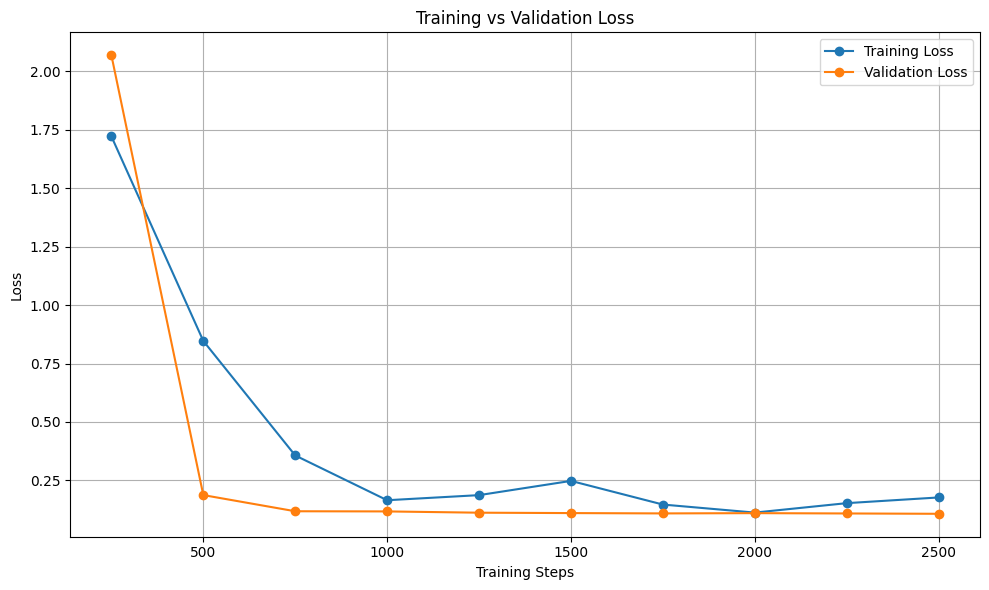

In [14]:
import matplotlib.pyplot as plt

# Data from your training log
steps = [250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500]
train_loss = [1.722400, 0.846900, 0.356800, 0.165200, 0.187000, 0.247900, 0.146700, 0.112300, 0.152700, 0.177100]
val_loss = [2.069362, 0.187212, 0.118009, 0.117313, 0.111844, 0.110200, 0.108780, 0.109946, 0.108591, 0.107148]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, marker='o', label='Training Loss')
plt.plot(steps, val_loss, marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
model.save_pretrained("./finetuned-flan-t5-vaccine_v3")
tokenizer.save_pretrained("./finetuned-flan-t5-vaccine_v3")

('./finetuned-flan-t5-vaccine_v3/tokenizer_config.json',
 './finetuned-flan-t5-vaccine_v3/special_tokens_map.json',
 './finetuned-flan-t5-vaccine_v3/spiece.model',
 './finetuned-flan-t5-vaccine_v3/added_tokens.json',
 './finetuned-flan-t5-vaccine_v3/tokenizer.json')

In [13]:
import shutil

shutil.make_archive('/content/finetuned-flan-t5-vaccine_v3', 'zip', '/content/finetuned-flan-t5-vaccine_v3')

from google.colab import files
files.download('/content/finetuned-flan-t5-vaccine_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>